In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/amazonreviews.tsv', sep = '\t')

In [4]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [5]:
df.shape

(10000, 2)

In [6]:
df.info(d)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [7]:
df.describe()

,label,review
count,10000,10000
unique,2,10000
top,neg,Early Hopkins story still sends chills through...
freq,5097,1


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Missing values before cleaning:
 label             0
review            0
cleaned_review    0
dtype: int64
Shape after cleaning: (10000, 3)

--- Feature Extraction (TF-IDF) ---
Training feature shape: (8000, 5000)
Testing feature shape: (2000, 5000)

--- Training Classification Model ---

--- Model Evaluation & Performance ---
Accuracy: 84.65%

Classification Report:
              precision    recall  f1-score   support

         neg       0.85      0.85      0.85      1019
         pos       0.85      0.84      0.84       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



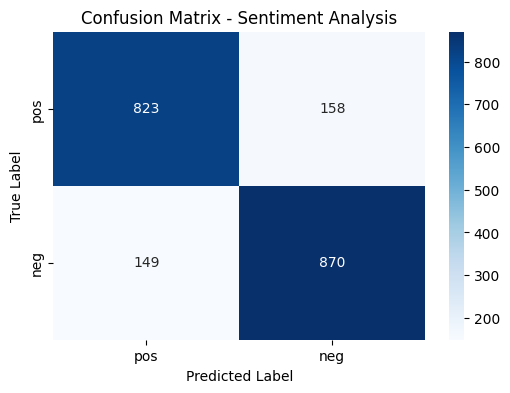

In [12]:
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords
import re
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
# Remove duplicate rows
df = df.drop_duplicates()

# Handle missing values (check & drop NaNs if any)
print('Missing values before cleaning:\n', df.isnull().sum())
df = df.dropna(subset=['review', 'label'])

# SText Preprocessing Function
# Includes lowercasing, punctuation removal, and stopword elimination
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    # Convert to lowercase
    text = text.lower()
    # Remove non-alphabetical characters (punctuation/numbers)
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize and filter out stopwords
    words = text.split()
    cleaned_words = [word for word in words if word not in stop_words]
    return ' '.join(cleaned_words)

# Apply preprocessing to the review text column
df['cleaned_review'] = df['review'].apply(preprocess_text)
print('Shape after cleaning:', df.shape)


# FEATURE EXTRACTION

print('\n--- Feature Extraction (TF-IDF) ---')

# Split features (X) and labels (y)
X = df['cleaned_review']
y = df['label']

# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize TF-IDF Vectorizer (limiting max features to prevent overfitting & ensure efficiency)
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit and transform training data, transform test data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f'Training feature shape: {X_train_tfidf.shape}')
print(f'Testing feature shape: {X_test_tfidf.shape}')


#  CLASSIFICATION MODELING

print('\n--- Training Classification Model ---')

# Train a robust baseline model: Multinomial Naive Bayes
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Predict on the test set
y_pred = model.predict(X_test_tfidf)


# 6. EVALUATION & INSIGHTS DISCUSSION

print('\n--- Model Evaluation & Performance ---')

# Calculate accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc * 100:.2f}%\n')

# Detailed classification report (Precision, Recall, F1-Score)
print('Classification Report:')
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['pos', 'neg'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['pos', 'neg'], yticklabels=['pos', 'neg'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Sentiment Analysis')
plt.show()

/tmp/ipykernel_5296/2896918918.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


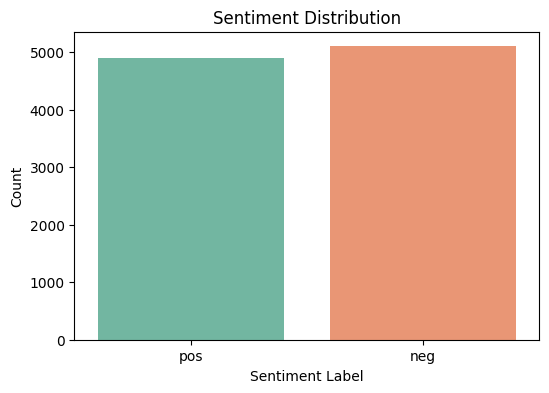

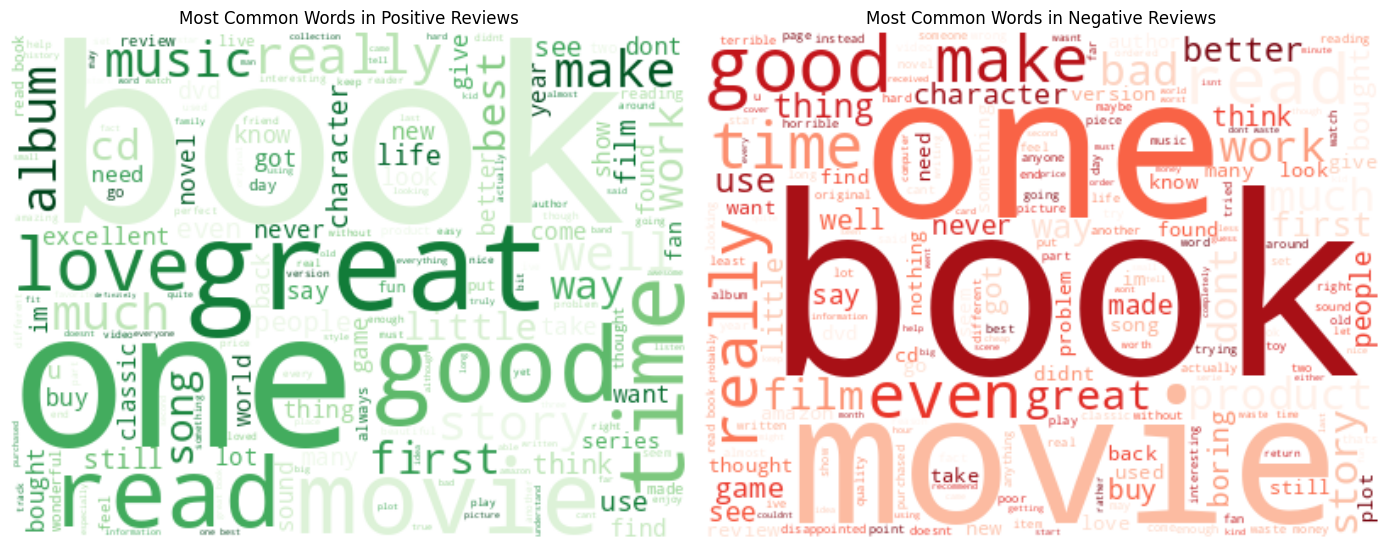

Top 10 Positive Words: [('book', 3313), ('great', 2087), ('one', 1835), ('good', 1635), ('read', 1553), ('like', 1268), ('movie', 1085), ('would', 943), ('love', 902), ('time', 871)]
Top 10 Negative Words: [('book', 3184), ('one', 2022), ('like', 1547), ('movie', 1465), ('would', 1438), ('dont', 1240), ('read', 1187), ('get', 1139), ('good', 1134), ('time', 1034)]


In [13]:
# EXPLORATORY DATA ANALYSIS (EDA)
from collections import Counter
from wordcloud import WordCloud

#  Sentiment Distribution Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

# Word Clouds for Positive and Negative Reviews
pos_text = ' '.join(df[df['label'] == 'pos']['cleaned_review'])
neg_text = ' '.join(df[df['label'] == 'neg']['cleaned_review'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive Word Cloud
pos_wc = WordCloud(
    width=400, height=300, background_color='white', colormap='Greens'
).generate(pos_text)
axes[0].imshow(pos_wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Common Words in Positive Reviews')

# Negative Word Cloud
neg_wc = WordCloud(
    width=400, height=300, background_color='white', colormap='Reds'
).generate(neg_text)
axes[1].imshow(neg_wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Common Words in Negative Reviews')

plt.tight_layout()
plt.show()


#  Most Common Positive/Negative Words (Bar Charts)
def get_top_words(text_series, n=10):
  all_words = ' '.join(text_series).split()
  return Counter(all_words).most_common(n)


top_pos_words = get_top_words(df[df['label'] == 'pos']['cleaned_review'], 10)
top_neg_words = get_top_words(df[df['label'] == 'neg']['cleaned_review'], 10)

print('Top 10 Positive Words:', top_pos_words)
print('Top 10 Negative Words:', top_neg_words)

In [14]:
#logistic Regression & SVM

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Train Logistic Regression
print("--- Training Logistic Regression ---")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred) * 100:.2f}%\n")
print("Logistic Regression Report:")
print(classification_report(y_test, lr_pred))

# Train Linear Support Vector Machine (SVM)
print("--- Training Linear SVM ---")
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)
print(f"SVM Accuracy: {accuracy_score(y_test, svm_pred) * 100:.2f}%\n")
print("SVM Report:")
print(classification_report(y_test, svm_pred))

--- Training Logistic Regression ---
Logistic Regression Accuracy: 85.60%

Logistic Regression Report:
              precision    recall  f1-score   support

         neg       0.86      0.86      0.86      1019
         pos       0.85      0.85      0.85       981

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

--- Training Linear SVM ---
SVM Accuracy: 84.50%

SVM Report:
              precision    recall  f1-score   support

         neg       0.85      0.84      0.85      1019
         pos       0.84      0.85      0.84       981

    accuracy                           0.84      2000
   macro avg       0.84      0.85      0.84      2000
weighted avg       0.85      0.84      0.85      2000



In [ ]:
#Why logistic - best linear baseline model that handles sparse TF-IDF feature matrices exceptionally well and provides probability scores for predictions.

In [ ]:
#Linear SVM (LinearSVC): Often outperforms Naive Bayes and Logistic Regression on text classification text datasets by finding the optimal hyperplane separating positive and negative sentiment boundaries with high margins.

In [16]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 25.9 MB/s eta 0:00:00


In [17]:
#ADVANCED MODEL DEVELOPMENT: Word2Vec Embeddings
from gensim.models import Word2Vec
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Tokenize the cleaned reviews for Word2Vec training
tokenized_reviews = [review.split() for review in df['cleaned_review']]

# 2. Train Word2Vec Model (
print("--- Training Word2Vec Model ---")
w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=2, workers=4)

# 3. Function to convert a review
def get_document_vector(words, model, vector_size=100):
    valid_words = [model.wv[word] for word in words if word in model.wv]
    if not valid_words:
        return np.zeros(vector_size)
    return np.mean(valid_words, axis=0)

# 4. Create document-level embeddings for train and test sets
X_train_tokens = [review.split() for review in X_train]
X_test_tokens = [review.split() for review in X_test]

X_train_w2v = np.array([get_document_vector(words, w2v_model) for words in X_train_tokens])
X_test_w2v = np.array([get_document_vector(words, w2v_model) for words in X_test_tokens])

print(f"Word2Vec Training Feature Shape: {X_train_w2v.shape}")
print(f"Word2Vec Testing Feature Shape: {X_test_w2v.shape}")

# 5. Train Logistic Regression using Word2Vec Embeddings
print("\n--- Training Classifier on Word2Vec Features ---")
w2v_lr_model = LogisticRegression(max_iter=1000, random_state=42)
w2v_lr_model.fit(X_train_w2v, y_train)

w2v_pred = w2v_lr_model.predict(X_test_w2v)
print(f"Word2Vec + Logistic Regression Accuracy: {accuracy_score(y_test, w2v_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, w2v_pred))

--- Training Word2Vec Model ---
Word2Vec Training Feature Shape: (8000, 100)
Word2Vec Testing Feature Shape: (2000, 100)

--- Training Classifier on Word2Vec Features ---
Word2Vec + Logistic Regression Accuracy: 74.35%

Classification Report:
              precision    recall  f1-score   support

         neg       0.74      0.76      0.75      1019
         pos       0.75      0.72      0.73       981

    accuracy                           0.74      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.74      0.74      0.74      2000



In [18]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression

# 1. Initialize our best-performing baseline model (Logistic Regression with TF-IDF)
cv_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Define the metrics we want to evaluate using 5-Fold Cross-Validation
scoring_metrics = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

print("--- Running 5-Fold Cross-Validation ---")
cv_results = cross_validate(cv_model, X_train_tfidf, y_train, cv=5, scoring=scoring_metrics)

# 3. Print out the average performance across all folds
print(f"Mean Cross-Validation Accuracy: {cv_results['test_accuracy'].mean() * 100:.2f}% (+/- {cv_results['test_accuracy'].std() * 100:.2f}%)")
print(f"Mean Cross-Validation F1-Score (Macro): {cv_results['test_f1_macro'].mean():.4f}")
print(f"Mean Precision (Macro): {cv_results['test_precision_macro'].mean():.4f}")
print(f"Mean Recall (Macro): {cv_results['test_recall_macro'].mean():.4f}")

--- Running 5-Fold Cross-Validation ---
Mean Cross-Validation Accuracy: 85.78% (+/- 0.51%)
Mean Cross-Validation F1-Score (Macro): 0.8577
Mean Precision (Macro): 0.8577
Mean Recall (Macro): 0.8577
